# Action–Variable Correlation Study: HumanoidMaze Medium

For each `humanoidmaze_medium_*.pt` model, we collect rollout trajectories and measure how much the model's **actions correlate with each observation variable**.

We use two complementary metrics:
1. **Canonical Correlation Analysis (CCA)** — captures multivariate linear dependence between the variable and the full action vector.
2. **Mutual Information estimate (via k-NN)** — captures nonlinear statistical dependence.

We also visualize per-variable **action variance explained** via a simple regression R².

In [1]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

from sklearn.cross_decomposition import CCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

from causal_gym import HumanoidMazePCH
from causal_rl.algo.imitation.imitate import (
    ContinuousPolicyNN,
    shared_policy_fn_long_horizon,
    make_shared_policy_dict,
    collect_imitator_trajectories,
    collect_expert_trajectories,
)
from causal_rl.algo.imitation.gail.core_net import ContinuousActor
from causal_rl.algo.imitation.gail.causal_gail import (
    build_windowed_z_encoder,
    make_gail_policy,
)

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1. Environment & Rollout Setup

In [3]:
NUM_STEPS = 1000
NUM_EPISODES = 50      # episodes per model (adjust for speed vs. accuracy)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_DIR = '/home/et2842/causal/causalrl/models'

# Variables the imitator sees (V is hidden)
IMITATOR_VARS = ['P', 'A', 'H', 'E', 'C', 'J', 'W']
# Include V from hidden_obs in info for the correlation study
ALL_VARS = ['P', 'A', 'H', 'E', 'V', 'C', 'J', 'W']

VAR_DIMS = {
    'P': 2,
    'A': 21,
    'H': 1,
    'E': 12,
    'V': 3,
    'C': 3,
    'J': 27,
    'W': 2,
}

## 2. Model Loading Helpers

In [4]:
def load_bc_model(path, device):
    """Load a BC-style checkpoint (expert, causal_bc, naive_bc)."""
    ckpt = torch.load(path, map_location=device, weights_only=False)
    action_bounds = (ckpt['action_bounds_low'], ckpt['action_bounds_high'])

    model = ContinuousPolicyNN(
        input_dim=ckpt['input_dim'],
        action_dim=ckpt['num_actions'],
        hidden_dim=ckpt['hidden_dim'],
        num_blocks=ckpt['num_blocks'],
        dropout=ckpt['dropout'],
        layernorm=ckpt['layernorm'],
        final_tanh=ckpt['final_tanh'],
        action_bounds=action_bounds,
    ).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    policy = shared_policy_fn_long_horizon(
        model, ckpt['slots'], ckpt['Z_trim'],
        continuous=True, device=device
    )
    return make_shared_policy_dict(policy), policy


def load_gail_model(path, device):
    """Load a GAIL-style checkpoint (causal_gail, naive_gail)."""
    ckpt = torch.load(path, map_location=device, weights_only=False)

    actor = ContinuousActor(
        num_inputs=ckpt['z_dim'],
        num_outputs=ckpt['action_dim'],
        hidden_size=ckpt['hidden_size_actor'],
        std=0.0,
        action_low=float(ckpt['action_bounds_low'].min()),
        action_high=float(ckpt['action_bounds_high'].max()),
        num_blocks=ckpt['num_blocks_actor'],
        dropout=ckpt['dropout_actor'],
        layernorm=ckpt['layernorm_actor'],
    ).to(device)
    actor.load_state_dict(ckpt['state_dict'])
    actor.eval()

    encode, _, _ = build_windowed_z_encoder(
        ckpt['Z_sets'], dims=ckpt['dims'], lookback=ckpt['lookback']
    )
    policy = make_gail_policy(actor, encode, device=device, deterministic=True)
    return make_shared_policy_dict(policy), policy

In [5]:
# Define all models to study
MODEL_SPECS = {
    'Expert': ('bc', 'humanoidmaze_medium_expert.pt'),
    'Expert (finetuned)': ('bc', 'humanoidmaze_medium_expert_finetuned.pt'),
    'Causal BC': ('bc', 'humanoidmaze_medium_causal_bc.pt'),
    'Naive BC': ('bc', 'humanoidmaze_medium_naive_bc.pt'),
    'Causal GAIL': ('gail', 'humanoidmaze_medium_causal_gail.pt'),
    'Naive GAIL': ('gail', 'humanoidmaze_medium_naive_gail.pt'),
}

policies = {}
policy_fns = {}
for name, (kind, fname) in MODEL_SPECS.items():
    path = os.path.join(MODEL_DIR, fname)
    if not os.path.exists(path):
        print(f'  [SKIP] {name}: {path} not found')
        continue
    if kind == 'bc':
        policies[name], policy_fns[name] = load_bc_model(path, device)
    else:
        policies[name], policy_fns[name] = load_gail_model(path, device)
    print(f'  Loaded {name}')

print(f'\nLoaded {len(policies)} models.')

  Loaded Expert
  Loaded Expert (finetuned)
  Loaded Causal BC
  Loaded Naive BC
  Loaded Causal GAIL
  Loaded Naive GAIL

Loaded 6 models.


## 3. Collect Trajectories

For each model we roll out `NUM_EPISODES` episodes in the environment (with V hidden, matching imitator conditions) and record both the actions taken and all observation variables (including V from hidden_obs).

In [6]:
def collect_data_for_model(model_name, policies_dict, num_episodes, num_steps, seed):
    """
    Roll out a policy and return arrays:
      var_arrays: dict  var_name -> np.ndarray of shape (N, var_dim)
      actions:    np.ndarray of shape (N, 21)
    where N = total timesteps across episodes.
    """
    # Expert models see V; imitator models don't
    is_expert = 'Expert' in model_name
    hidden_dims = set() if is_expert else {'V'}

    env = HumanoidMazePCH(
        env_id='humanoidmaze-medium-navigate-singletask-task1-v0',
        num_steps=num_steps,
        expert_mode=is_expert,
        custom_hidden=hidden_dims,
        seed=seed,
    )

    records = collect_imitator_trajectories(
        env, policies_dict,
        num_episodes=num_episodes,
        max_steps=num_steps,
        hidden_dims=hidden_dims,
        seed=seed,
    )

    # Extract per-step variable values and actions
    var_data = {v: [] for v in ALL_VARS}
    action_data = []

    for rec in records:
        t = rec['step']
        obs = rec['obs']
        info = rec['info']

        # Current action
        action_data.append(np.asarray(rec['action'], dtype=np.float32))

        # Current observation variables (take the last entry = current timestep)
        for v in ALL_VARS:
            if v in obs and len(obs[v]) > 0:
                val = np.asarray(obs[v][-1], dtype=np.float32).ravel()
                var_data[v].append(val)
            elif 'hidden_obs' in info and v in info['hidden_obs']:
                hidden_hist = info['hidden_obs'][v]
                if len(hidden_hist) > 0:
                    val = np.asarray(hidden_hist[-1], dtype=np.float32).ravel()
                    var_data[v].append(val)
                else:
                    var_data[v].append(np.zeros(VAR_DIMS[v], dtype=np.float32))
            else:
                var_data[v].append(np.zeros(VAR_DIMS[v], dtype=np.float32))

    env.close()

    var_arrays = {v: np.stack(var_data[v], axis=0) for v in ALL_VARS}
    actions = np.stack(action_data, axis=0)
    return var_arrays, actions

In [7]:
all_data = {}
for name in policies:
    print(f'Collecting trajectories for {name}...')
    var_arrays, actions = collect_data_for_model(
        name, policies[name], NUM_EPISODES, NUM_STEPS, SEED
    )
    all_data[name] = (var_arrays, actions)
    print(f'  -> {actions.shape[0]} timesteps collected')

  -> 50000 timesteps collected
  -> 50000 timesteps collected
  -> 50000 timesteps collected
  -> 50000 timesteps collected
  -> 50000 timesteps collected
  -> 50000 timesteps collected


## 4. Correlation Analysis Functions

In [8]:
def compute_mean_cca(X, Y, n_components=None):
    """
    Mean canonical correlation between X (N, d_x) and Y (N, d_y).
    Returns the average of the top canonical correlations.
    """
    if X.shape[1] == 0 or Y.shape[1] == 0:
        return 0.0
    n_comp = n_components or min(X.shape[1], Y.shape[1], 10)
    n_comp = min(n_comp, X.shape[1], Y.shape[1])

    sx = StandardScaler().fit_transform(X)
    sy = StandardScaler().fit_transform(Y)

    cca = CCA(n_components=n_comp, max_iter=500)
    try:
        Xc, Yc = cca.fit_transform(sx, sy)
        corrs = [np.corrcoef(Xc[:, i], Yc[:, i])[0, 1] for i in range(n_comp)]
        return float(np.nanmean(np.abs(corrs)))
    except Exception:
        return 0.0


def compute_r2(X, Y):
    """
    R² of a Ridge regression predicting Y (actions) from X (variable).
    Measures variance in actions explained by the variable.
    """
    if X.shape[1] == 0:
        return 0.0
    sx = StandardScaler().fit_transform(X)
    sy = StandardScaler().fit_transform(Y)
    reg = Ridge(alpha=1.0).fit(sx, sy)
    return float(max(0.0, reg.score(sx, sy)))


def compute_mi(X, Y, n_neighbors=5):
    """
    Average mutual information between variable X and each action dimension.
    Uses sklearn's k-NN MI estimator.
    """
    if X.shape[1] == 0 or Y.shape[1] == 0:
        return 0.0
    # Subsample for speed
    N = min(X.shape[0], 5000)
    idx = np.random.choice(X.shape[0], N, replace=False)
    Xs = X[idx]
    Ys = Y[idx]
    mi_vals = []
    for j in range(Ys.shape[1]):
        mi = mutual_info_regression(Xs, Ys[:, j], n_neighbors=n_neighbors, random_state=0)
        mi_vals.append(mi.mean())
    return float(np.mean(mi_vals))

## 5. Compute All Metrics

In [9]:
results_cca = {}
results_r2 = {}
results_mi = {}

for model_name, (var_arrays, actions) in all_data.items():
    print(f'\nAnalysing {model_name}...')
    cca_row = {}
    r2_row = {}
    mi_row = {}

    for v in ALL_VARS:
        X = var_arrays[v]
        cca_row[v] = compute_mean_cca(X, actions)
        r2_row[v] = compute_r2(X, actions)
        mi_row[v] = compute_mi(X, actions)
        print(f'  {v:>2s} (dim={X.shape[1]:2d}):  CCA={cca_row[v]:.3f}  R²={r2_row[v]:.3f}  MI={mi_row[v]:.3f}')

    results_cca[model_name] = cca_row
    results_r2[model_name] = r2_row
    results_mi[model_name] = mi_row


Analysing Expert...
   P (dim= 2):  CCA=0.169  R²=0.005  MI=0.442
   A (dim=21):  CCA=0.701  R²=0.465  MI=0.245
   H (dim= 1):  CCA=0.827  R²=0.091  MI=0.539
   E (dim=12):  CCA=0.544  R²=0.288  MI=0.379
   V (dim= 3):  CCA=0.688  R²=0.164  MI=0.472
   C (dim= 3):  CCA=0.407  R²=0.035  MI=0.247
   J (dim=27):  CCA=0.604  R²=0.270  MI=0.204
   W (dim= 2):  CCA=0.690  R²=0.112  MI=0.215

Analysing Expert (finetuned)...
   P (dim= 2):  CCA=0.170  R²=0.005  MI=0.471
   A (dim=21):  CCA=0.700  R²=0.453  MI=0.297
   H (dim= 1):  CCA=0.848  R²=0.099  MI=0.592
   E (dim=12):  CCA=0.541  R²=0.294  MI=0.429
   V (dim= 3):  CCA=0.676  R²=0.166  MI=0.550
   C (dim= 3):  CCA=0.421  R²=0.038  MI=0.263
   J (dim=27):  CCA=0.609  R²=0.280  MI=0.193
   W (dim= 2):  CCA=0.692  R²=0.116  MI=0.211

Analysing Causal BC...
   P (dim= 2):  CCA=0.183  R²=0.005  MI=0.729
   A (dim=21):  CCA=0.740  R²=0.573  MI=0.447
   H (dim= 1):  CCA=0.896  R²=0.186  MI=0.638
   E (dim=12):  CCA=0.531  R²=0.385  MI=0.658
  

## 6. Summary Tables

In [10]:
df_cca = pd.DataFrame(results_cca).T[ALL_VARS]
df_r2 = pd.DataFrame(results_r2).T[ALL_VARS]
df_mi = pd.DataFrame(results_mi).T[ALL_VARS]

print('=== Mean Canonical Correlation (CCA) ===')
display(df_cca.round(3).style.background_gradient(cmap='YlOrRd', axis=None))

=== Mean Canonical Correlation (CCA) ===


,P,A,H,E,V,C,J,W
Expert,0.169000,0.701000,0.827000,0.544000,0.688000,0.407000,0.604000,0.690000
Expert (finetuned),0.170000,0.700000,0.848000,0.541000,0.676000,0.421000,0.609000,0.692000
Causal BC,0.183000,0.740000,0.896000,0.531000,0.522000,0.330000,0.534000,0.446000
Naive BC,0.344000,0.787000,0.574000,0.594000,0.770000,0.271000,0.518000,0.845000
Causal GAIL,0.642000,0.864000,0.506000,0.592000,0.525000,0.285000,0.510000,0.505000
Naive GAIL,0.556000,0.841000,0.622000,0.613000,0.656000,0.325000,0.500000,0.728000


In [11]:
print('=== R² (variance in actions explained by variable) ===')
display(df_r2.round(3).style.background_gradient(cmap='YlOrRd', axis=None))

=== R² (variance in actions explained by variable) ===


,P,A,H,E,V,C,J,W
Expert,0.005000,0.465000,0.091000,0.288000,0.164000,0.035000,0.270000,0.112000
Expert (finetuned),0.005000,0.453000,0.099000,0.294000,0.166000,0.038000,0.280000,0.116000
Causal BC,0.005000,0.573000,0.186000,0.385000,0.188000,0.018000,0.168000,0.052000
Naive BC,0.026000,0.716000,0.014000,0.566000,0.413000,0.019000,0.116000,0.376000
Causal GAIL,0.063000,0.820000,0.015000,0.556000,0.139000,0.012000,0.094000,0.095000
Naive GAIL,0.058000,0.861000,0.016000,0.620000,0.139000,0.012000,0.068000,0.107000


In [12]:
print('=== Mutual Information (nonlinear dependence) ===')
display(df_mi.round(3).style.background_gradient(cmap='YlOrRd', axis=None))

=== Mutual Information (nonlinear dependence) ===


,P,A,H,E,V,C,J,W
Expert,0.442000,0.245000,0.539000,0.379000,0.472000,0.247000,0.204000,0.215000
Expert (finetuned),0.471000,0.297000,0.592000,0.429000,0.550000,0.263000,0.193000,0.211000
Causal BC,0.729000,0.447000,0.638000,0.658000,0.725000,0.446000,0.358000,0.278000
Naive BC,1.059000,0.672000,1.026000,0.958000,1.081000,0.377000,0.316000,0.587000
Causal GAIL,2.935000,1.570000,2.278000,2.018000,2.432000,1.139000,0.718000,0.675000
Naive GAIL,2.531000,1.021000,1.667000,1.644000,1.981000,0.598000,0.376000,0.799000


## 7. Visualizations

In [13]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150,
})

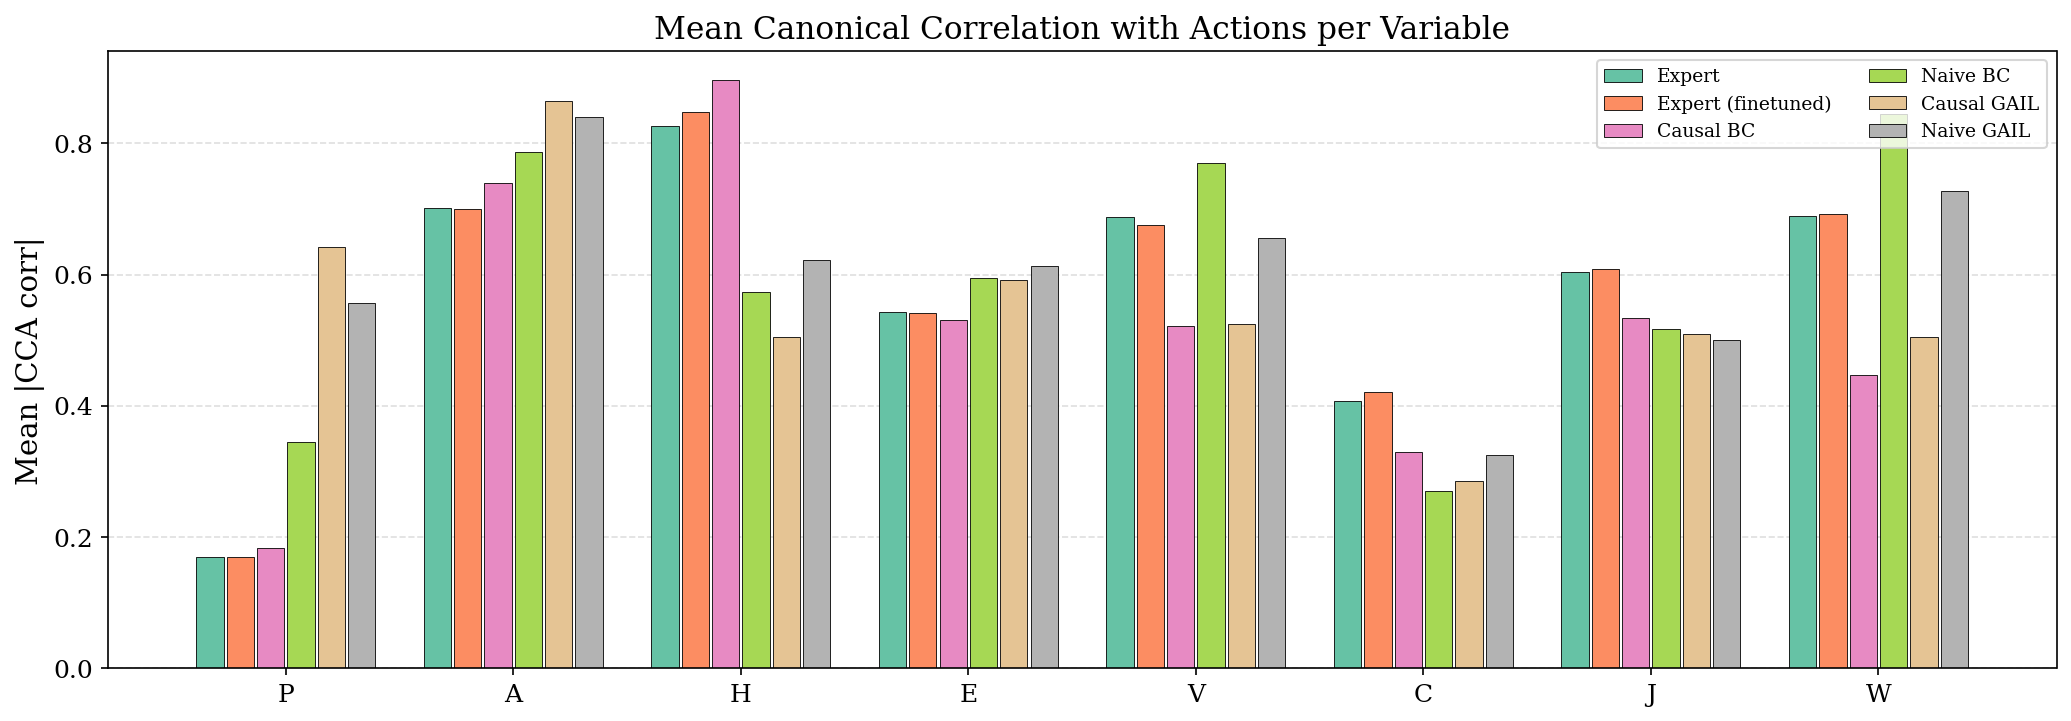

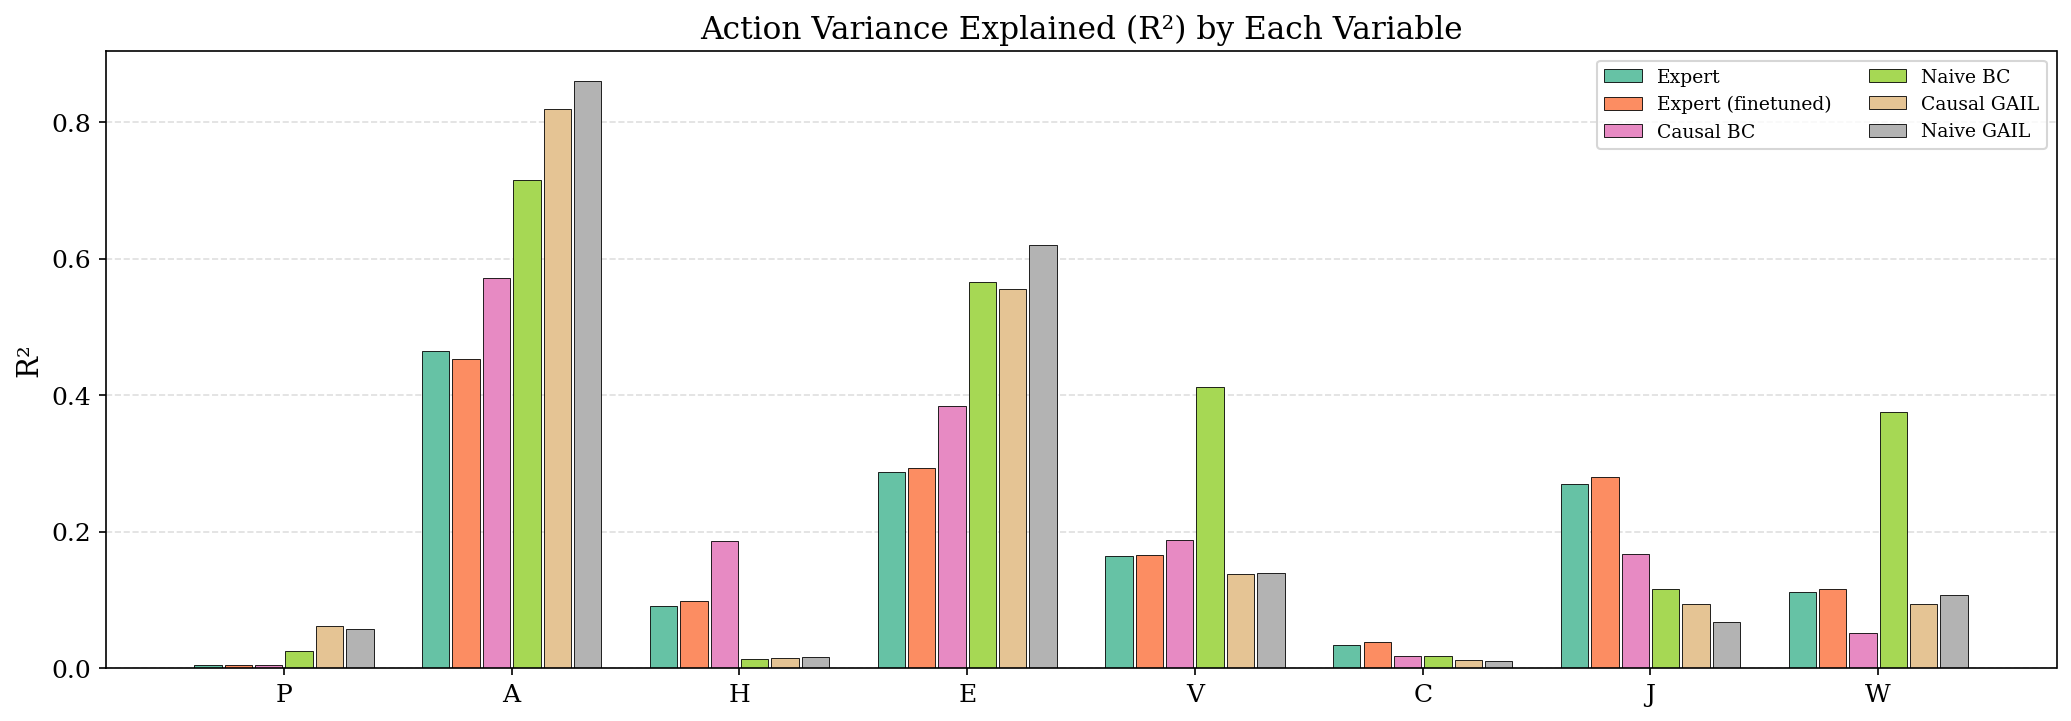

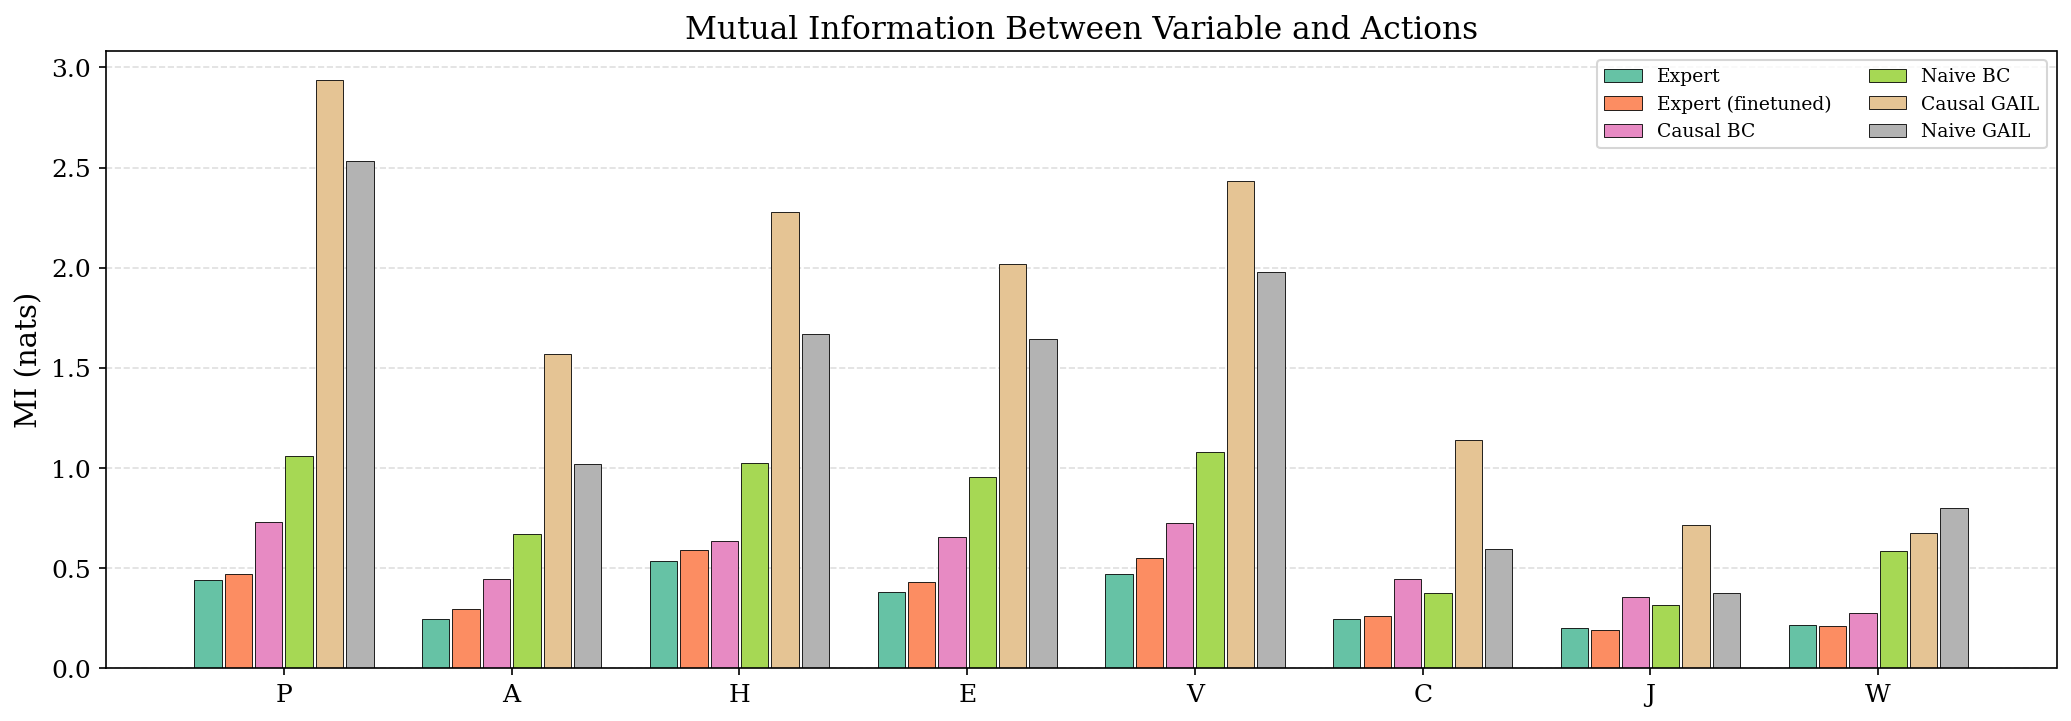

In [14]:
def plot_grouped_bar(df, title, ylabel, filename=None):
    """Grouped bar chart: one group per variable, one bar per model."""
    models = df.index.tolist()
    variables = df.columns.tolist()
    n_models = len(models)
    n_vars = len(variables)

    x = np.arange(n_vars)
    width = 0.8 / n_models

    colors = plt.cm.Set2(np.linspace(0, 1, n_models))

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, model in enumerate(models):
        offset = (i - n_models / 2 + 0.5) * width
        vals = df.loc[model].values
        ax.bar(x + offset, vals, width * 0.9, label=model, color=colors[i], edgecolor='black', linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(variables)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9, ncol=2, loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


plot_grouped_bar(df_cca, 'Mean Canonical Correlation with Actions per Variable', 'Mean |CCA corr|', 'hummaze_cca.pdf')
plot_grouped_bar(df_r2, 'Action Variance Explained (R²) by Each Variable', 'R²', 'hummaze_r2.pdf')
plot_grouped_bar(df_mi, 'Mutual Information Between Variable and Actions', 'MI (nats)', 'hummaze_mi.pdf')

### 7b. Heatmaps

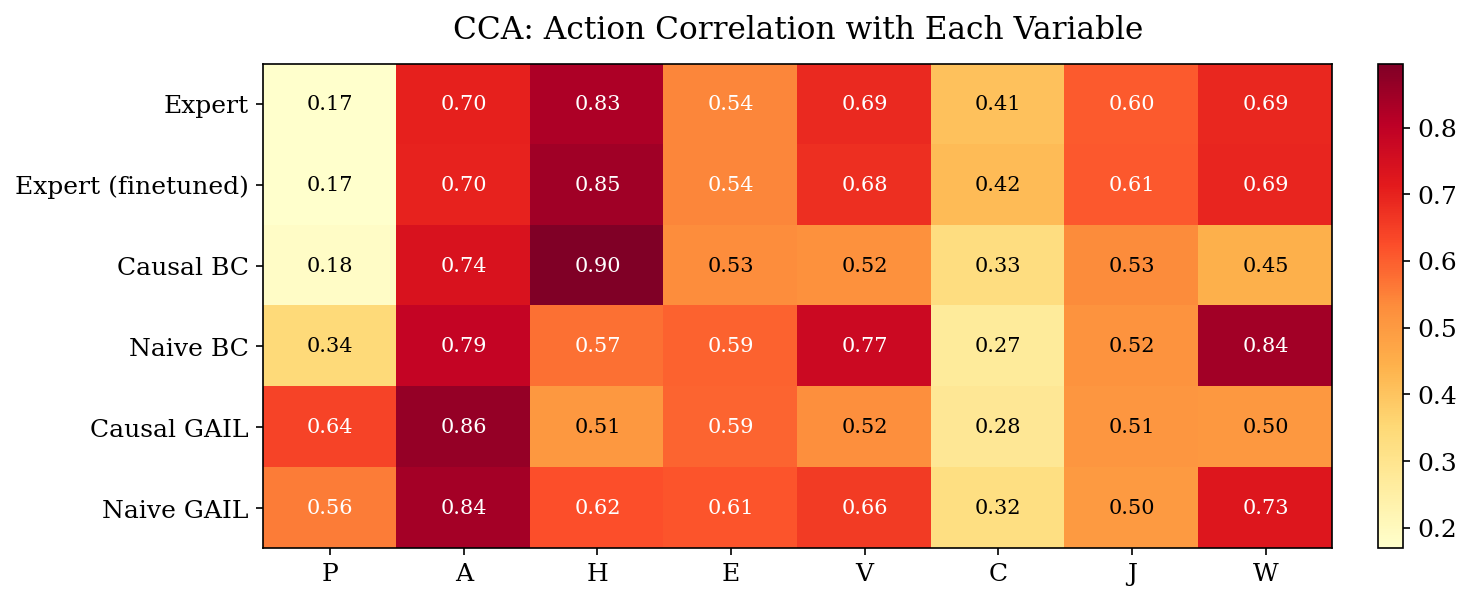

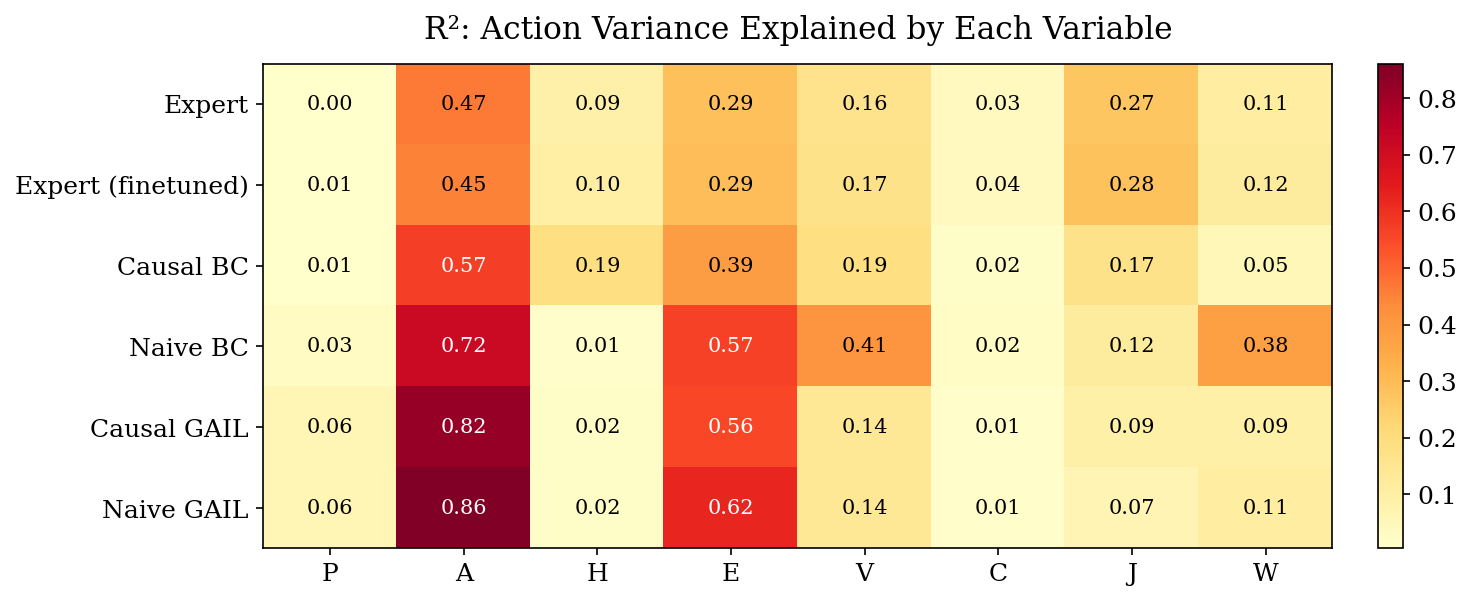

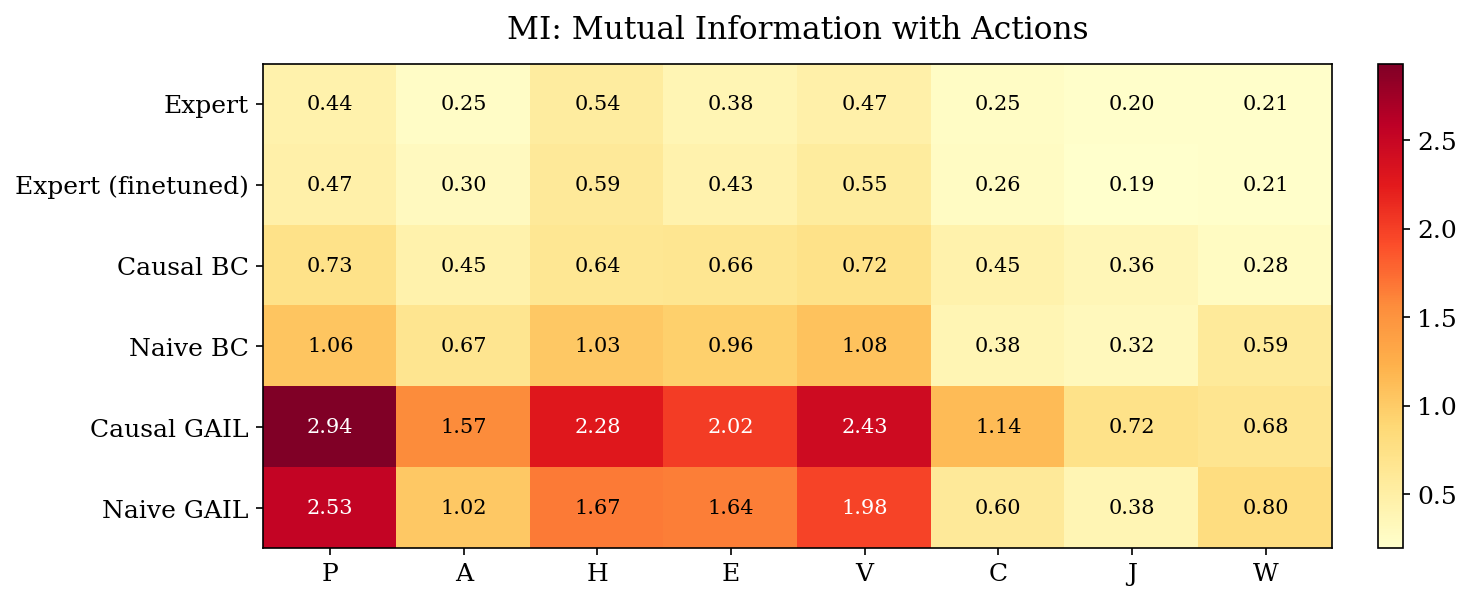

In [15]:
def plot_heatmap(df, title, filename=None):
    fig, ax = plt.subplots(figsize=(10, max(3, len(df) * 0.7)))
    im = ax.imshow(df.values, aspect='auto', cmap='YlOrRd')

    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns)
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    # Annotate cells
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            val = df.values[i, j]
            color = 'white' if val > (df.values.max() * 0.6) else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color=color)

    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    ax.set_title(title, pad=12)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


plot_heatmap(df_cca, 'CCA: Action Correlation with Each Variable', 'hummaze_cca_heatmap.pdf')
plot_heatmap(df_r2, 'R²: Action Variance Explained by Each Variable', 'hummaze_r2_heatmap.pdf')
plot_heatmap(df_mi, 'MI: Mutual Information with Actions', 'hummaze_mi_heatmap.pdf')

## 8. Zooming in on V (Hidden Variable)

The key causal question: **do imitator policies' actions still vary with V**, even though V is hidden?
If so, the policy has learned a spurious dependence on V through the confounded proxy W.

In [16]:
print('Action dependence on V (hidden torso vertical):\n')
print(f'{"Model":<25s} {"CCA":>8s} {"R²":>8s} {"MI":>8s}')
print('-' * 55)
for name in policies:
    print(f'{name:<25s} {results_cca[name]["V"]:8.3f} {results_r2[name]["V"]:8.3f} {results_mi[name]["V"]:8.3f}')

Action dependence on V (hidden torso vertical):

Model                          CCA       R²       MI
-------------------------------------------------------
Expert                       0.688    0.164    0.472
Expert (finetuned)           0.676    0.166    0.550
Causal BC                    0.522    0.188    0.725
Naive BC                     0.770    0.413    1.081
Causal GAIL                  0.525    0.139    2.432
Naive GAIL                   0.656    0.139    1.981


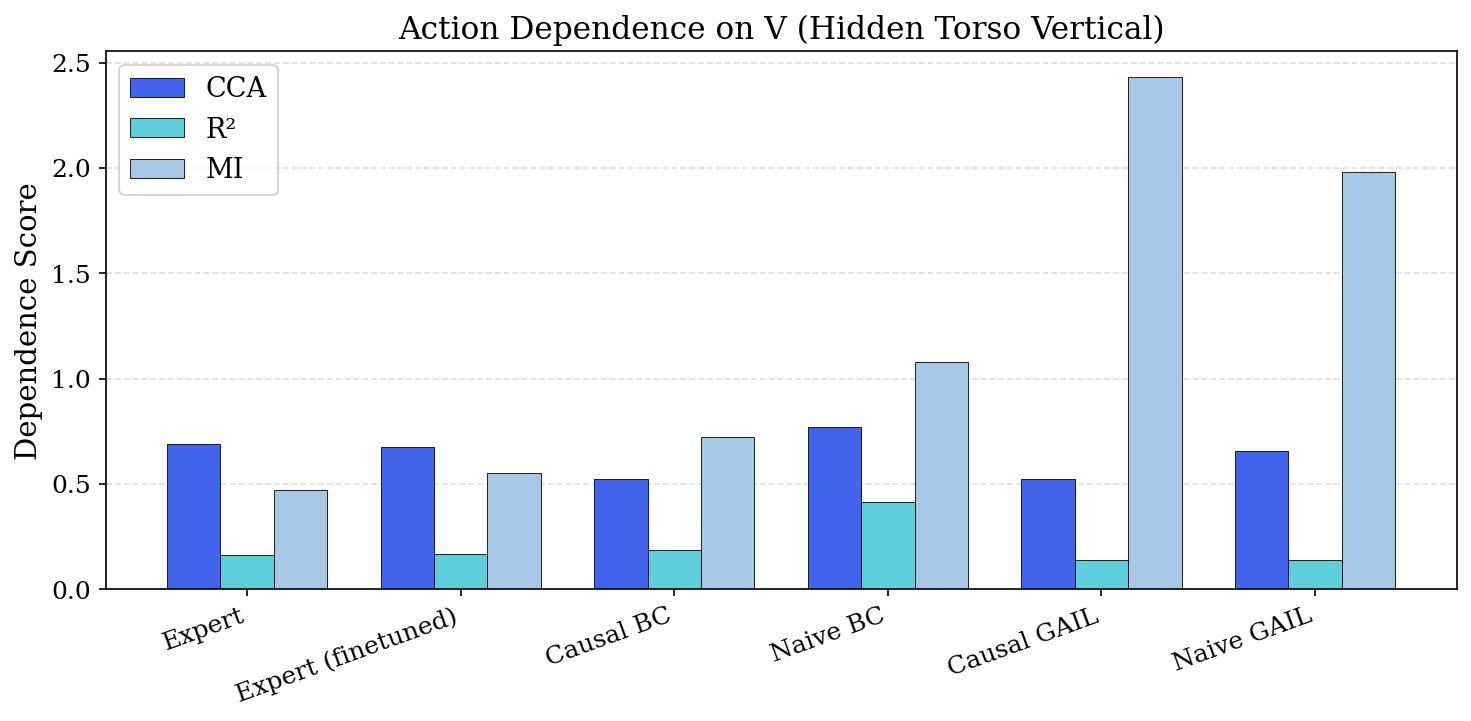

In [17]:
# Bar chart: V-dependence across models
model_names = list(policies.keys())
v_cca = [results_cca[m]['V'] for m in model_names]
v_r2 = [results_r2[m]['V'] for m in model_names]
v_mi = [results_mi[m]['V'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, v_cca, width, label='CCA', color='#4263EB', edgecolor='black', linewidth=0.4)
ax.bar(x, v_r2, width, label='R²', color='#5ECEDB', edgecolor='black', linewidth=0.4)
ax.bar(x + width, v_mi, width, label='MI', color='#A7C7E7', edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Dependence Score')
ax.set_title('Action Dependence on V (Hidden Torso Vertical)')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('hummaze_v_dependence.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 9. Per-Action-Dimension Breakdown

Which individual action dimensions are most correlated with each variable? This shows the fine-grained structure.

/tmp/ipykernel_1910229/4205892139.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


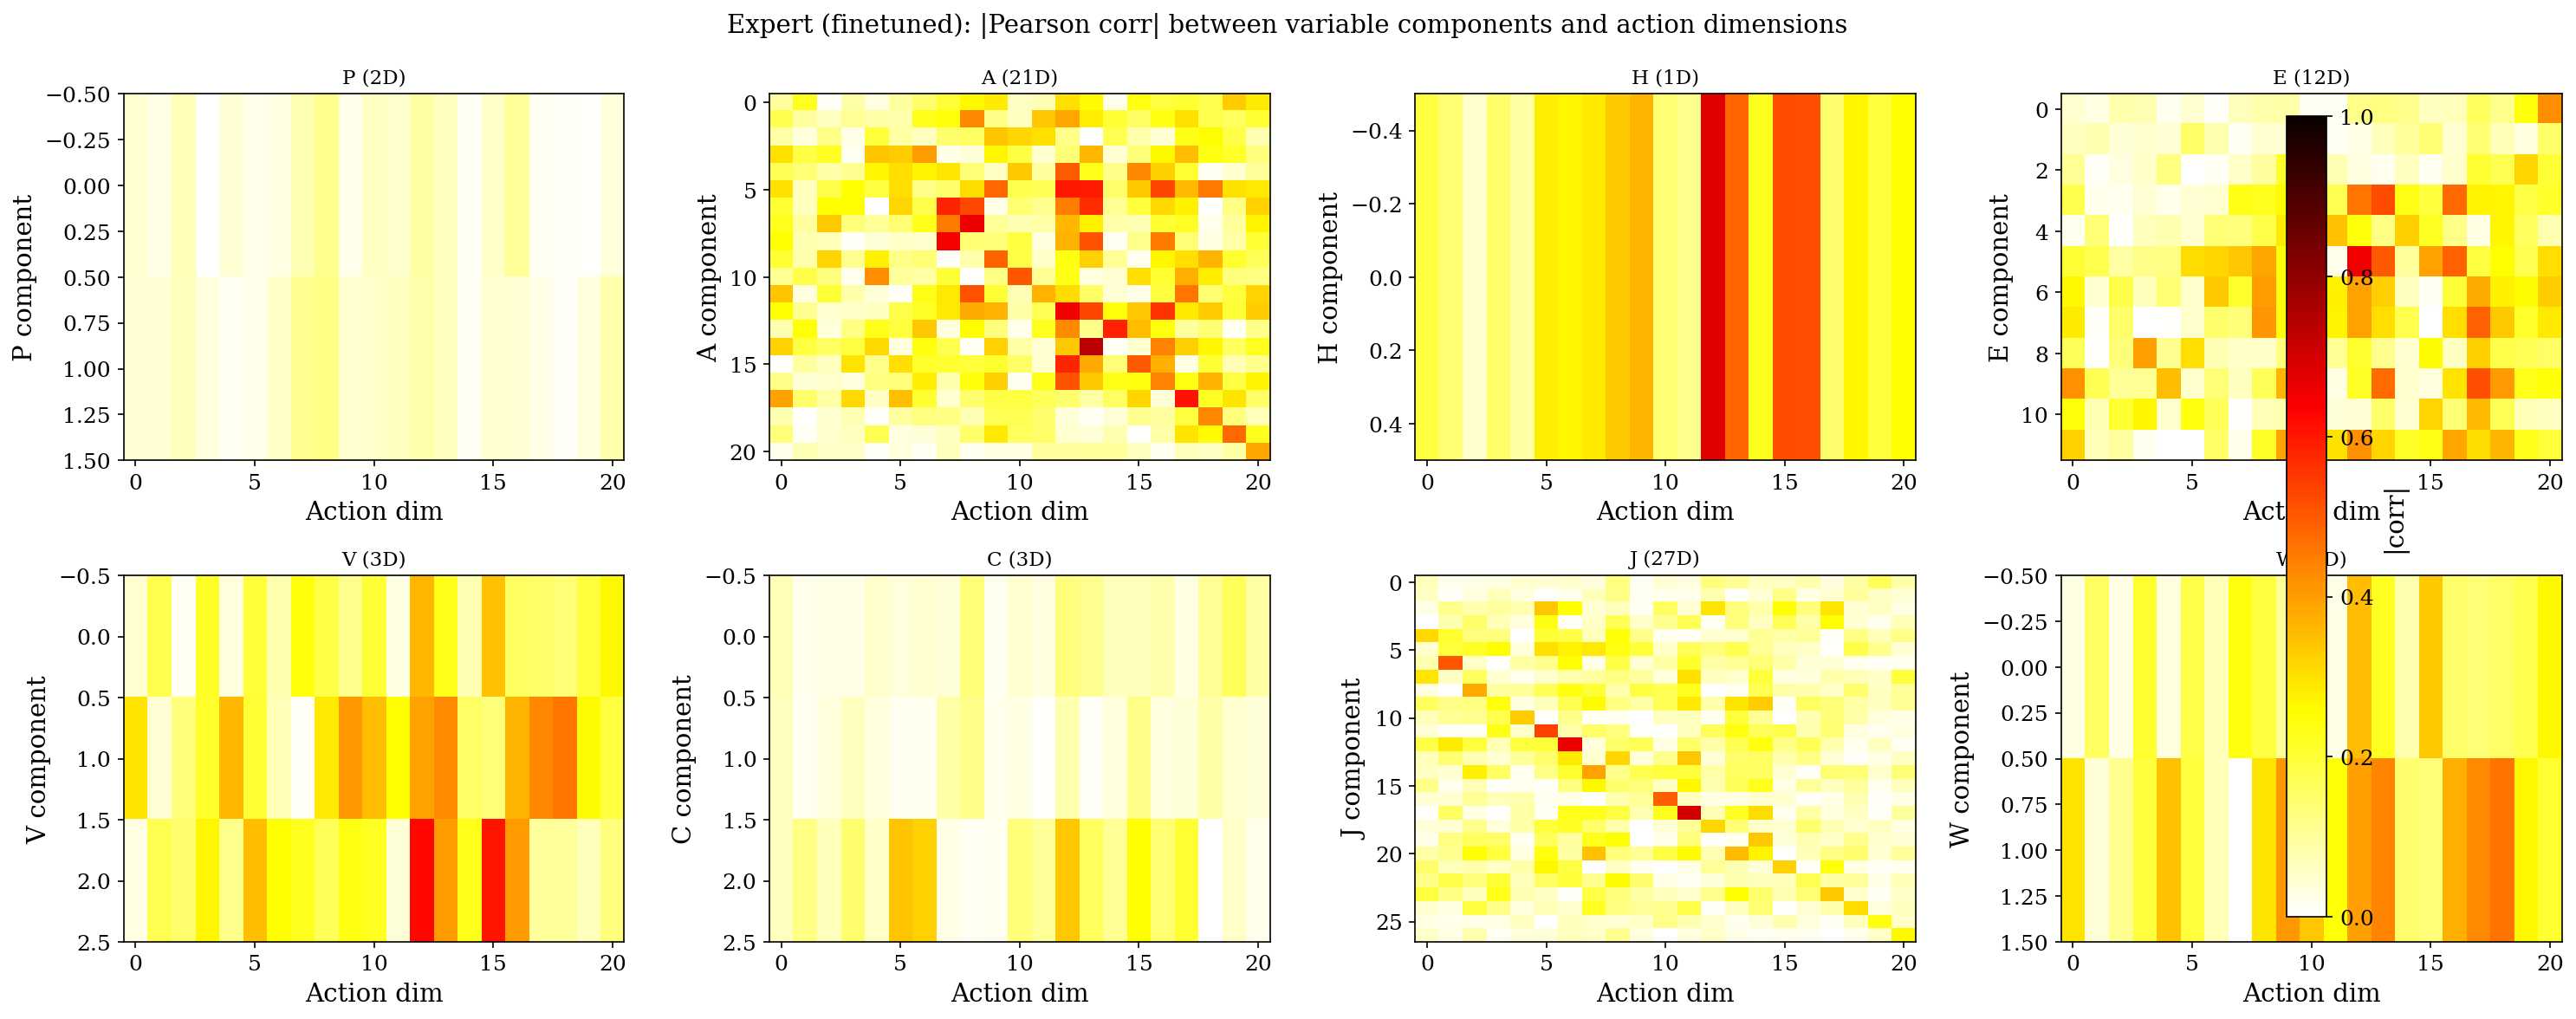

/tmp/ipykernel_1910229/4205892139.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


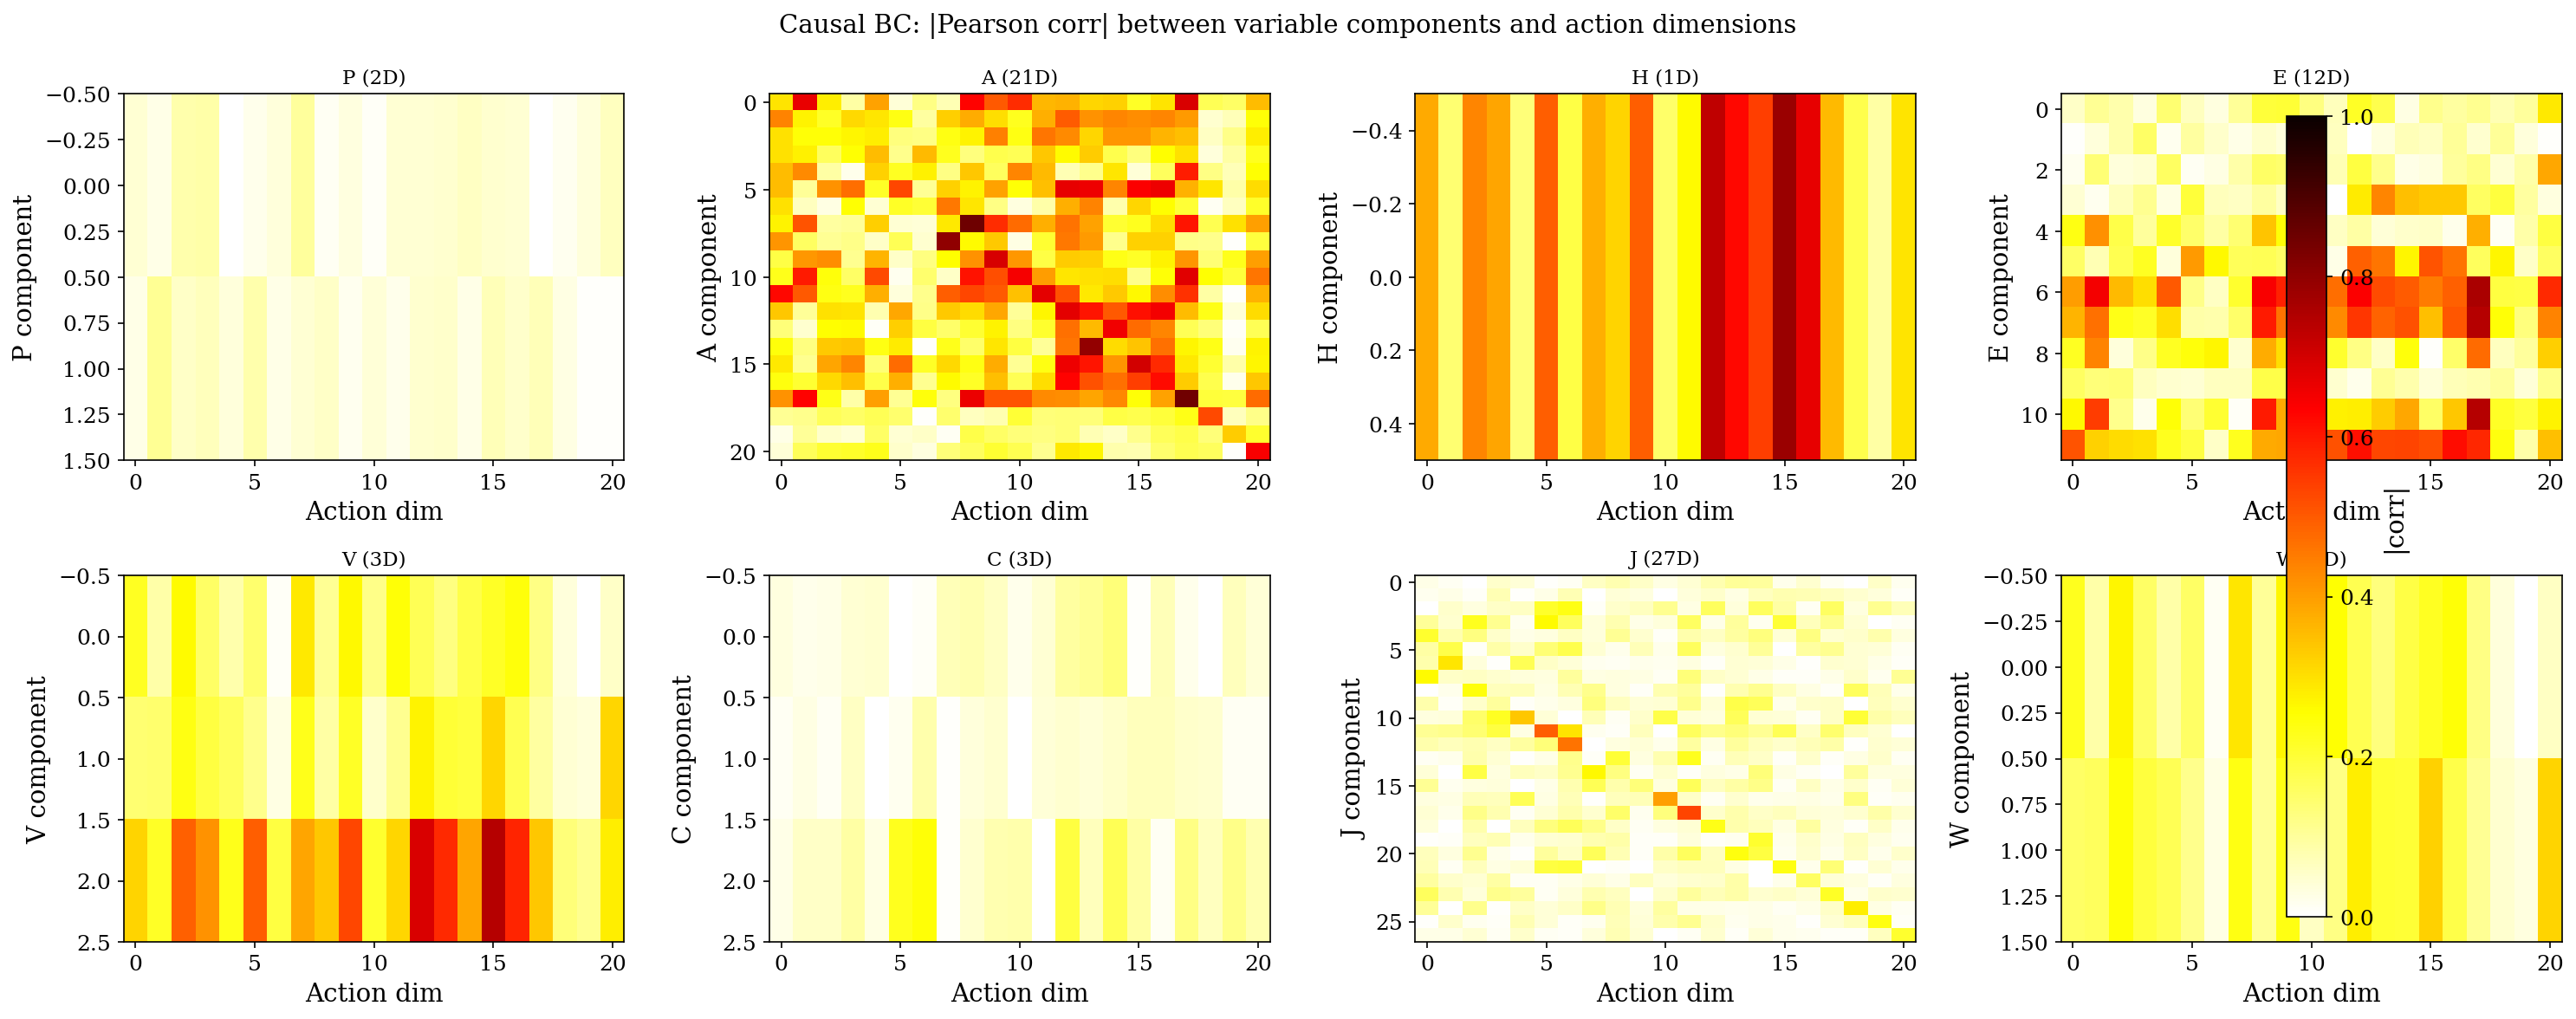

/tmp/ipykernel_1910229/4205892139.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


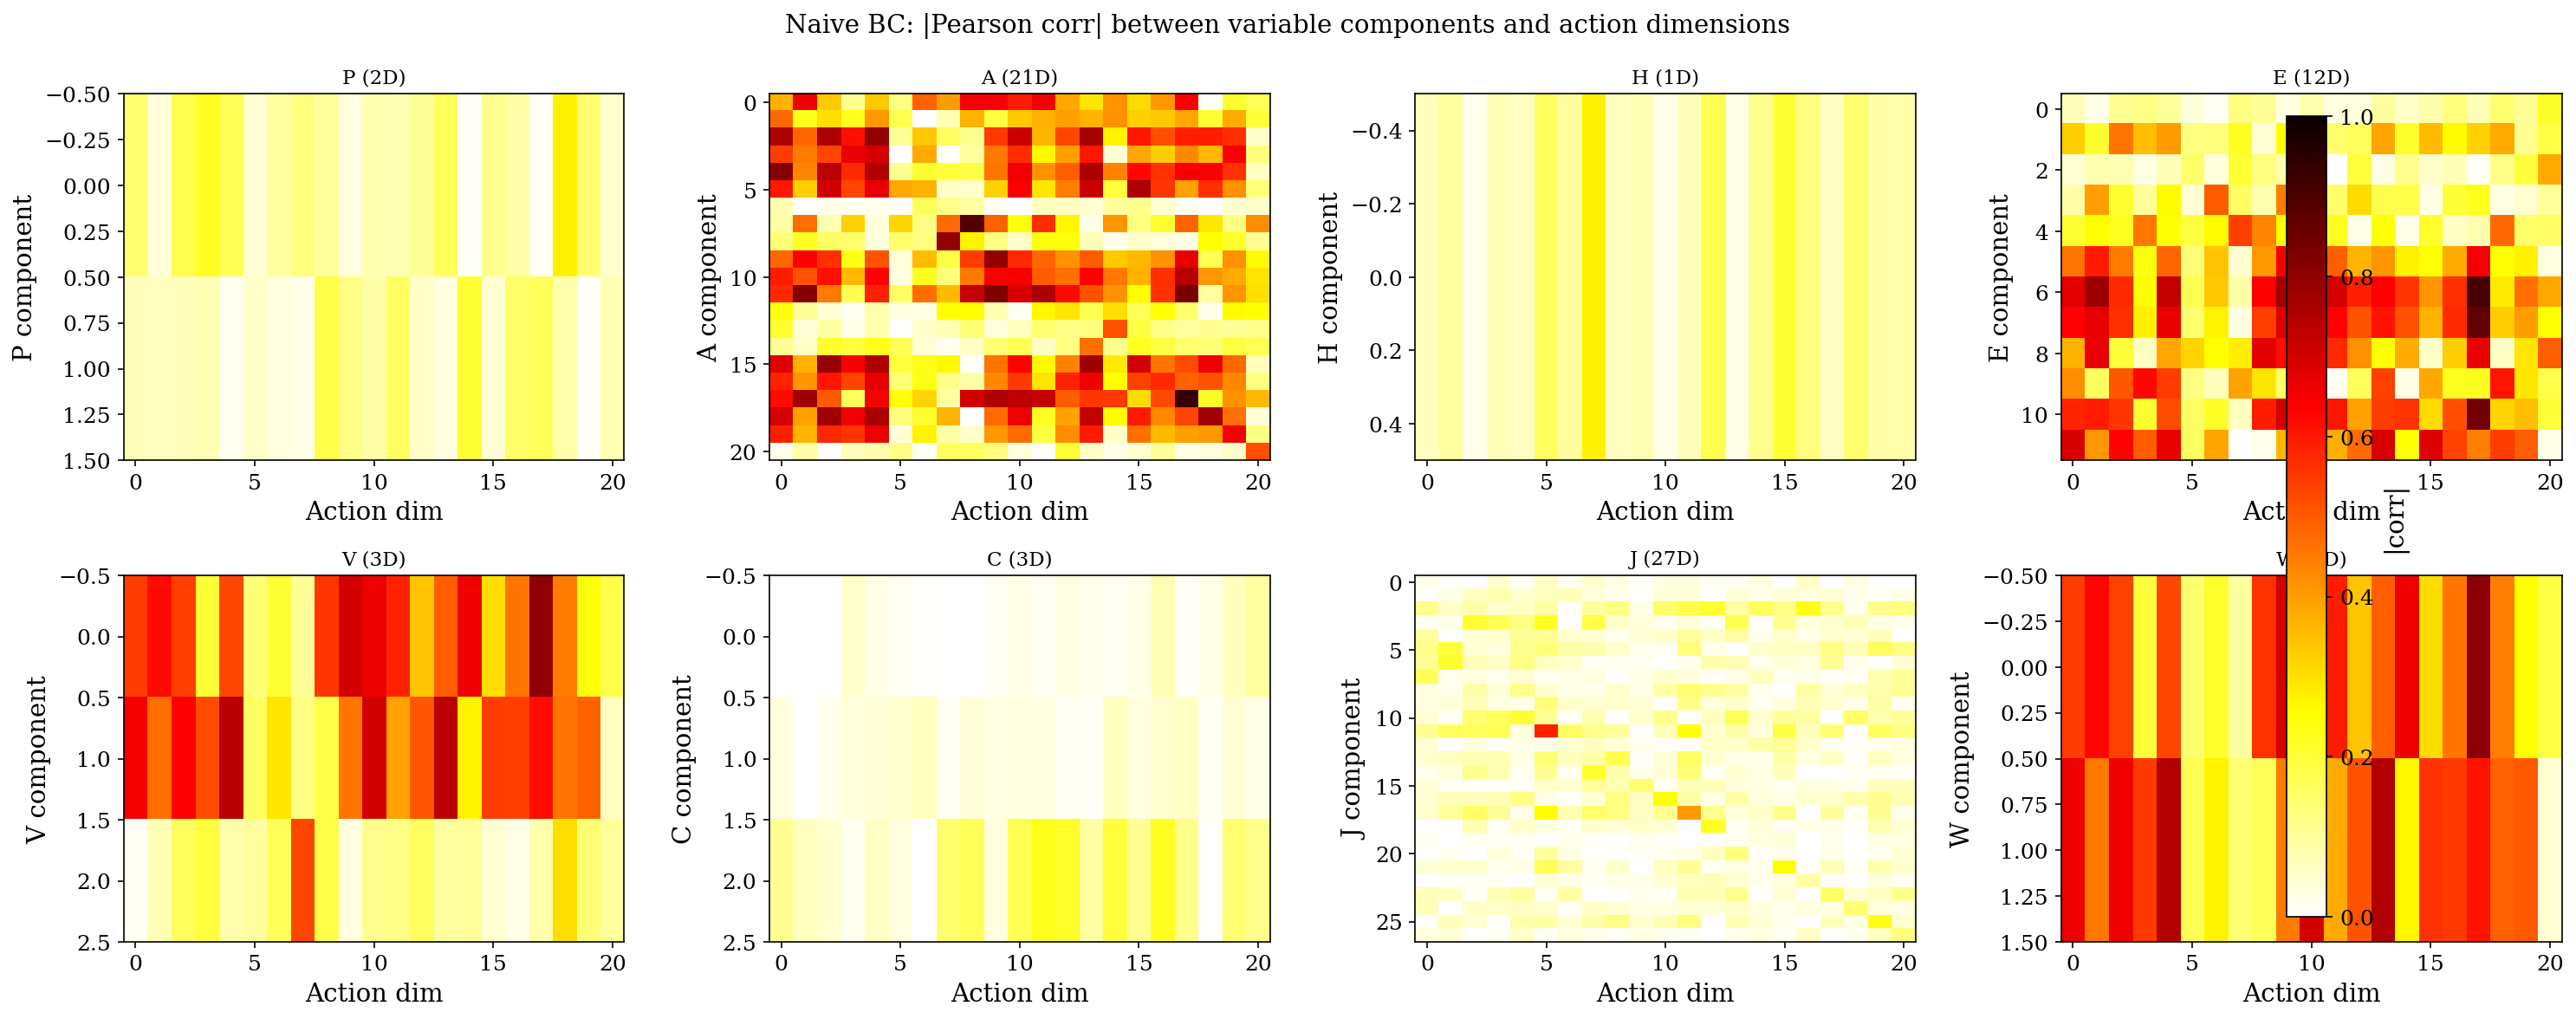

In [18]:
def per_action_dim_correlations(var_arrays, actions, var_name):
    """
    For a single variable, compute the absolute Pearson correlation
    between each component of that variable and each action dimension.
    Returns a matrix of shape (var_dim, action_dim).
    """
    X = var_arrays[var_name]  # (N, d_v)
    A = actions                # (N, 21)

    # Standardize
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    A = (A - A.mean(0)) / (A.std(0) + 1e-8)

    # Correlation matrix: (d_v, 21)
    corr = (X.T @ A) / X.shape[0]
    return np.abs(corr)


# Pick a model to examine in detail
focus_models = ['Expert (finetuned)', 'Causal BC', 'Naive BC']
focus_models = [m for m in focus_models if m in all_data]

for model_name in focus_models:
    var_arrays, actions = all_data[model_name]

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(f'{model_name}: |Pearson corr| between variable components and action dimensions', fontsize=14)

    for idx, v in enumerate(ALL_VARS):
        ax = axes[idx // 4, idx % 4]
        corr_mat = per_action_dim_correlations(var_arrays, actions, v)
        im = ax.imshow(corr_mat, aspect='auto', cmap='hot_r', vmin=0, vmax=1)
        ax.set_title(f'{v} ({corr_mat.shape[0]}D)', fontsize=11)
        ax.set_xlabel('Action dim')
        ax.set_ylabel(f'{v} component')

    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label='|corr|')
    plt.tight_layout()
    plt.savefig(f'hummaze_perdim_{model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()

## 10. Action Variance Conditioned on Variable Bins

For each variable, we bin its values into quantiles and check how much the **mean action** changes across bins. High variation = strong dependence.

In [19]:
def action_variance_across_bins(var_arrays, actions, var_name, n_bins=10):
    """
    Bin the first principal component of variable `var_name` into quantiles,
    then compute the variance of mean-action across bins (normalized by total action variance).
    This is essentially eta-squared.
    """
    X = var_arrays[var_name]  # (N, d_v)

    # Use first PC as a scalar summary
    Xc = X - X.mean(0)
    if X.shape[1] > 1:
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        pc1 = Xc @ Vt[0]  # project onto 1st PC
    else:
        pc1 = Xc[:, 0]

    # Quantile bins
    quantiles = np.percentile(pc1, np.linspace(0, 100, n_bins + 1))
    quantiles[-1] += 1e-6
    bin_idx = np.digitize(pc1, quantiles) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    # Mean action per bin
    grand_mean = actions.mean(0)
    ss_between = 0.0
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        bin_mean = actions[mask].mean(0)
        ss_between += mask.sum() * np.sum((bin_mean - grand_mean) ** 2)

    ss_total = np.sum((actions - grand_mean) ** 2)
    eta2 = ss_between / (ss_total + 1e-12)
    return float(eta2)


results_eta2 = {}
for model_name, (var_arrays, actions) in all_data.items():
    row = {}
    for v in ALL_VARS:
        row[v] = action_variance_across_bins(var_arrays, actions, v)
    results_eta2[model_name] = row

df_eta2 = pd.DataFrame(results_eta2).T[ALL_VARS]

print('=== Eta² (action variance explained by variable bins) ===')
display(df_eta2.round(3).style.background_gradient(cmap='YlOrRd', axis=None))

=== Eta² (action variance explained by variable bins) ===


,P,A,H,E,V,C,J,W
Expert,0.018000,0.182000,0.217000,0.180000,0.165000,0.061000,0.126000,0.133000
Expert (finetuned),0.031000,0.194000,0.201000,0.174000,0.153000,0.066000,0.127000,0.136000
Causal BC,0.038000,0.422000,0.294000,0.322000,0.236000,0.166000,0.190000,0.154000
Naive BC,0.092000,0.656000,0.389000,0.617000,0.509000,0.069000,0.118000,0.480000
Causal GAIL,0.120000,0.425000,0.160000,0.380000,0.183000,0.087000,0.114000,0.091000
Naive GAIL,0.118000,0.496000,0.300000,0.361000,0.252000,0.076000,0.052000,0.115000


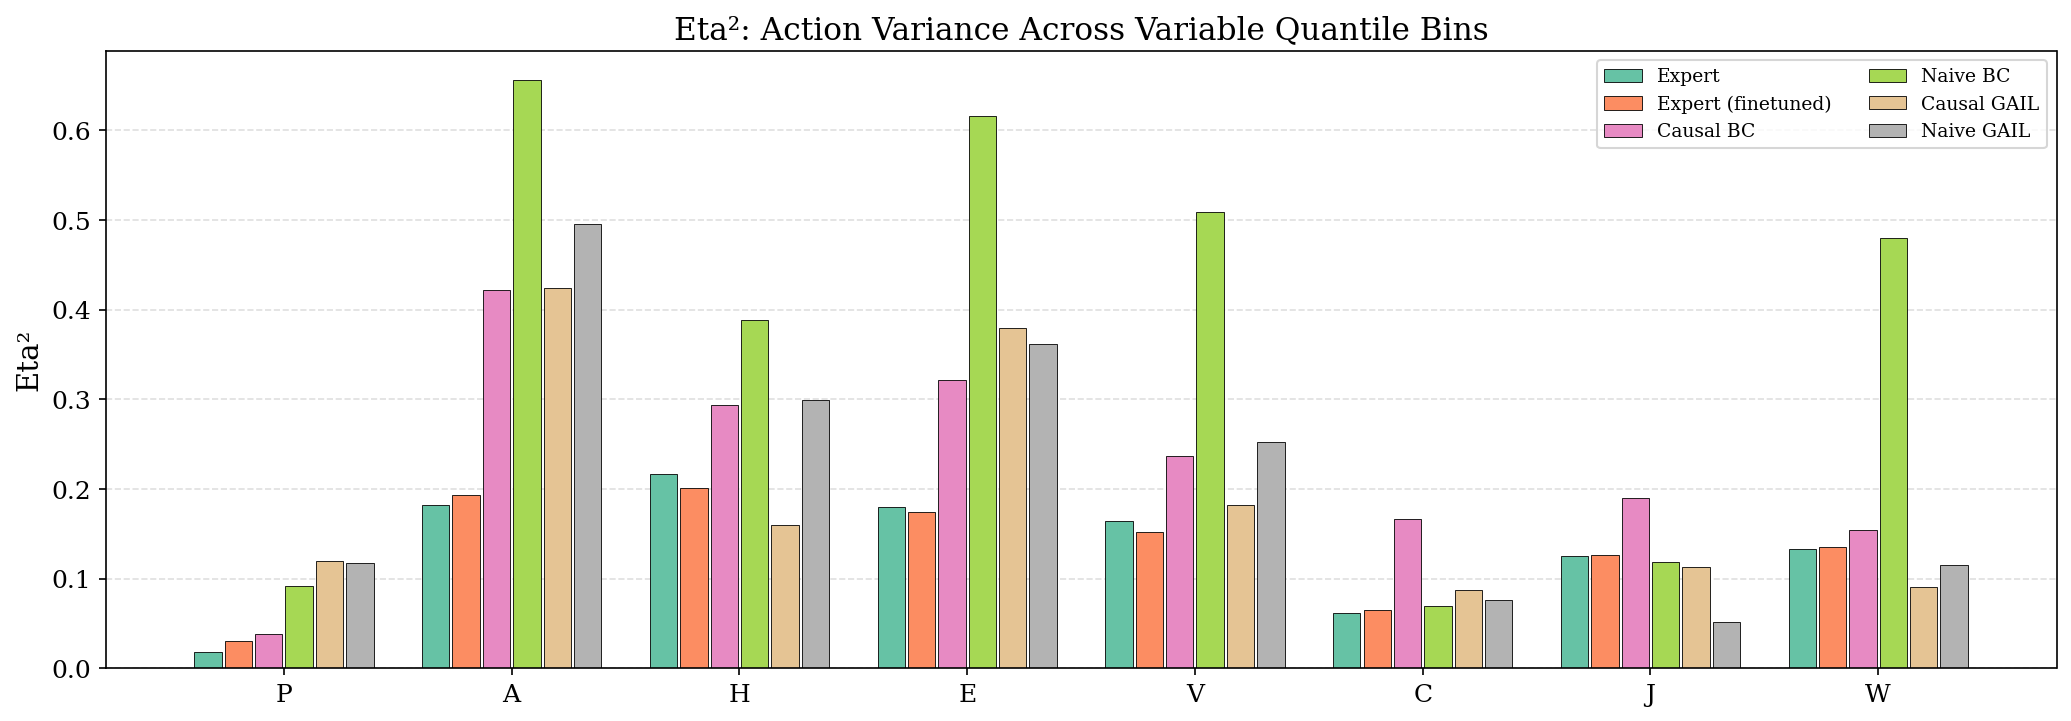

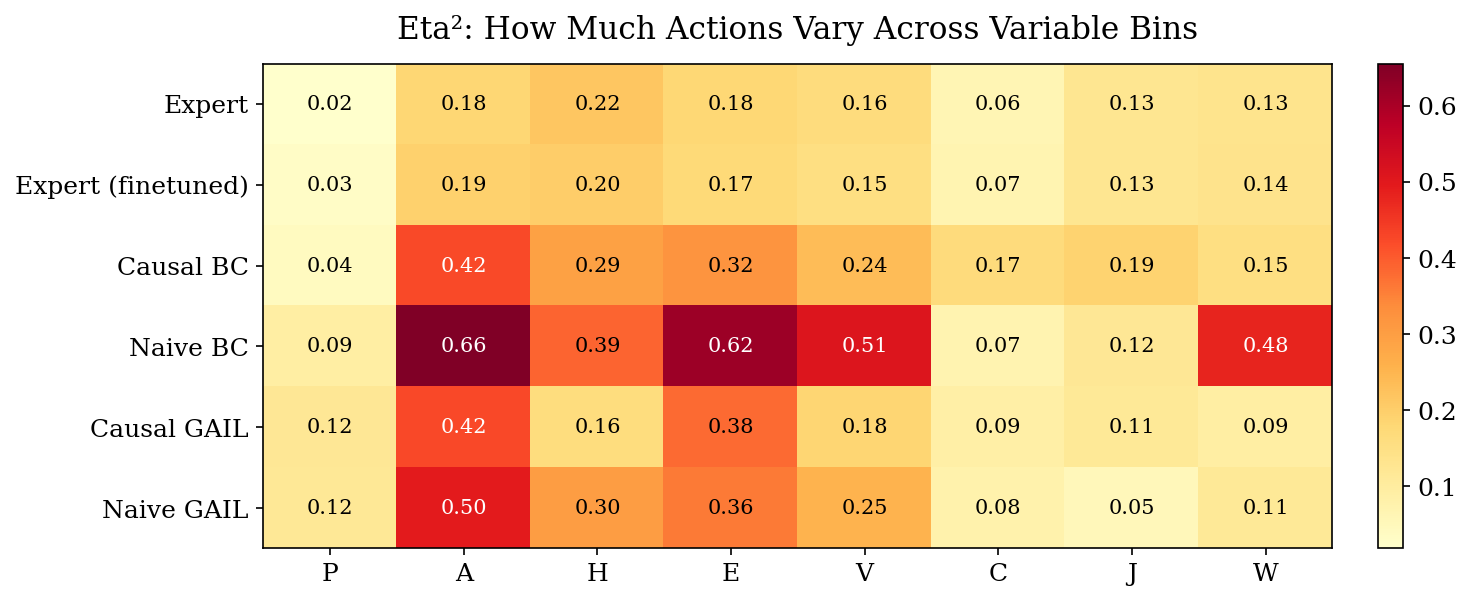

In [20]:
plot_grouped_bar(df_eta2, 'Eta²: Action Variance Across Variable Quantile Bins', 'Eta²', 'hummaze_eta2.pdf')
plot_heatmap(df_eta2, 'Eta²: How Much Actions Vary Across Variable Bins', 'hummaze_eta2_heatmap.pdf')

## 11. Summary

Combine all metrics for a final comparison.

In [21]:
# Average across all variables for an overall "dependence profile"
summary = []
for name in policies:
    row = {'Model': name}
    for metric, res in [('CCA', results_cca), ('R²', results_r2), ('MI', results_mi), ('Eta²', results_eta2)]:
        for v in ALL_VARS:
            row[f'{metric}({v})'] = res[name][v]
        row[f'{metric}_mean'] = np.mean([res[name][v] for v in ALL_VARS])
    summary.append(row)

df_summary = pd.DataFrame(summary).set_index('Model')

# Show just the mean scores
mean_cols = [c for c in df_summary.columns if '_mean' in c]
print('=== Average dependence across all variables ===')
display(df_summary[mean_cols].round(3))

=== Average dependence across all variables ===


,CCA_mean,R²_mean,MI_mean,Eta²_mean
Model,,,,
Expert,0.579,0.179,0.343,0.135
Expert (finetuned),0.582,0.181,0.376,0.135
Causal BC,0.523,0.197,0.535,0.228
Naive BC,0.588,0.281,0.760,0.366
Causal GAIL,0.553,0.224,1.721,0.195
Naive GAIL,0.605,0.235,1.327,0.221


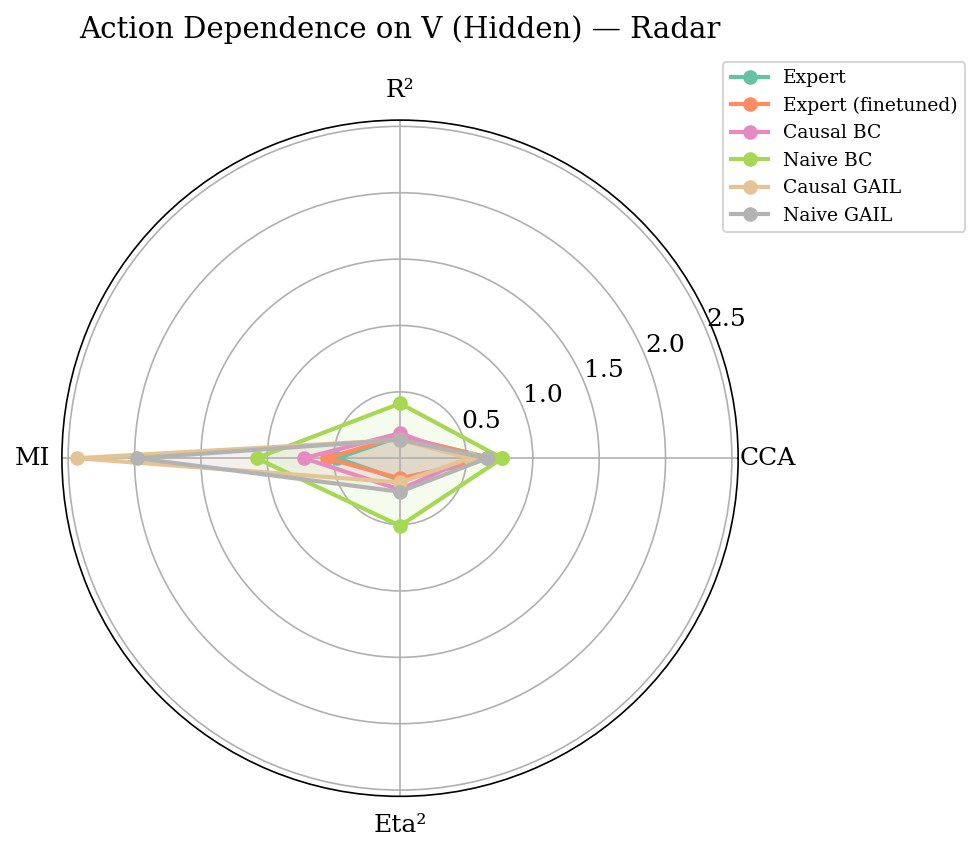

In [22]:
# Radar chart of V-dependence
metrics = ['CCA', 'R²', 'MI', 'Eta²']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, len(policies)))

for i, name in enumerate(policies):
    values = [
        results_cca[name]['V'],
        results_r2[name]['V'],
        results_mi[name]['V'],
        results_eta2[name]['V'],
    ]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Action Dependence on V (Hidden) — Radar', pad=20, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('hummaze_v_radar.pdf', dpi=300, bbox_inches='tight')
plt.show()